In [1]:
#!pip install langchain python-dotenv langchain_community arxiv wikipedia pymupdf langchain-text-splitters langchain_huggingface streamlit langchain_groq youtube_transcript_api cassio tiktoken PyPDF2 langgraph langchain_core langchain_classic langchainhub pydantic

In [2]:
import sys
sys.modules["tensorflow"] = None
sys.modules["keras"] = None
sys.modules["tf_keras"] = None

import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import imageio_ffmpeg
FFMPEG_PATH = imageio_ffmpeg.get_ffmpeg_exe()
os.environ["FFMPEG_BINARY"] = FFMPEG_PATH

In [3]:
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader, WebBaseLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.vectorstores import Cassandra
from langchain_google_genai import ChatGoogleGenerativeAI

C:\Users\KAUSTUBH\final_genai_project_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
from dotenv import load_dotenv
load_dotenv(dotenv_path=".env")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")
ASTRA_DB_TOKEN = os.getenv("ASTRA_DB_TOKEN")
ASTRA_DB_ID = os.getenv("ASTRA_DB_ID")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

In [5]:
# Initializing LLM
#llm = ChatGroq(groq_api_key=GROQ_API_KEY,model_name="llama-3.1-8b-instant")
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.9)
# response = llm.invoke("Write a short story about a robot discovering music.")
# response

In [6]:
# HuggingFace Embedding initialization
hf_embeddings = HuggingFaceEmbeddings(
                    model_name = "all-MiniLM-L6-v2",
                    model_kwargs={"device": "cpu"}
                )

In [7]:
import cassio
cassio.init(token=ASTRA_DB_TOKEN, database_id=ASTRA_DB_ID)

In [8]:
# AstraDB Initialization
astra_vector_store = Cassandra(embedding=hf_embeddings,
                               table_name="pdfquery_db",
                               session=None,
                               keyspace=None)

In [9]:
def data_ingestion(path_or_url, type_):
    if(type_=="pdf"):
        documents = []
        # for uploaded_file in uploaded_files:
        #     temp_pdf = "./temp.pdf"
        #     with open(temp_pdf, "wb") as file:
        #         file.write(uploaded_file.getvalue())
        #         file_name = uploaded_file.name

        pdf_loader = PyPDFLoader(path_or_url)
        docs = pdf_loader.load()
        documents.extend(docs) #append documents
        return documents
    elif(type_=="web"):
        web_loader = WebBaseLoader(path_or_url)
        docs = web_loader.load()
        return docs

In [10]:
def chunking(docs, type_):
    if(type_=="pdf"):
        text_splitter = RecursiveCharacterTextSplitter(chunk_size=5000,chunk_overlap=500)
        docs_split = text_splitter.split_documents(docs)
        return docs_split
    elif(type_=="web"):
        text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
        docs_split = text_splitter.split_documents(docs)
        return docs_split

In [11]:
def update_vectorstore(docs_split):
  astra_vector_store.clear()
  astra_vector_store.add_documents(docs_split)
  # retriever = astra_vector_store.as_retriever(search_kwargs={"k":3})
  # return retriever

def reset_vectorstore():
    pass

In [12]:
#documents = data_ingestion("./Attention.pdf","pdf")
documents = data_ingestion("https://docs.langchain.com/oss/python/langchain/overview","web")
docs_split = chunking(documents,"web")
update_vectorstore(docs_split)

In [13]:
from langchain_core.prompts import ChatPromptTemplate

router_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """Decide where to route the question.

Choose ONE:
- wiki_search
- browser_search
- youtube_summarize

Rules:
- Use youtube_summarize if the question contains a YouTube link
- Use browser_search for recent or changing info
- Use wiki_search for general knowledge

Return ONLY the datasource name."""),
    ("human", "{question}")
])

In [14]:
from typing import TypedDict, List

class GraphState(TypedDict):
  question: str
  datasource: str
  documents: List[str]
  answer: str

In [15]:
def vectorstore_check_node(state: GraphState):
    question = state["question"]

    results = astra_vector_store.similarity_search_with_score(
        question, k=1
    )

    if not results:
        return {"datasource": "router"}

    _, score = results[0]
    print("Score-----------------------------------------------")
    print(score)
    if score >= 0.7:
        return {"datasource": "vectorstore"}
    else:
        return {"datasource": "router"}


In [16]:
# Router Node
def router_node(state: GraphState):
    response = llm.invoke(
        router_prompt.format_messages(
            question=state["question"]
        )
    )

    return {"datasource": response.content.strip()}

In [17]:
# VectorStore Node
from langchain_core.prompts import ChatPromptTemplate

rag_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """You are a helpful AI assistant.
Answer the question strictly using the provided context, and give detailed explanation.
If the answer is not present in the context, say "I don't know based on the provided documents."""),
    ("human",
     """Context:
{context}

Question:
{question}""")
])

def vectorstore_node(state: GraphState):
    question = state["question"]

    docs = astra_vector_store.similarity_search_with_score(question,k=3)

    # Combine retrieved chunks to create context
    context = "\n\n".join(str(doc[0]) for doc in docs)

    # Invoking LLM to generate response
    response = llm.invoke(
        rag_prompt.format_messages(
            context=context,
            question=question
        )
    )
    print("--------------------------------------------------------------------------------")
    print(response)
    return {
        "answer": str(response.content),
        "documents": docs
    }


In [18]:
# Wikipedia Search Node
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wiki_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a factual assistant. Answer ONLY using the provided Wikipedia content. "
        "Generate a verbose response only when asked to."
        "Do not use external knowledge or assumptions."
    ),
    (
        "human",
        "Wikipedia content:\n{wiki_content}\n\n"
        "Question:\n{question}\n\n"
        "If the content is insufficient, say so explicitly."
    )
])

wiki = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(top_k_results=3)
)

def wiki_node(state: GraphState):
    question = state["question"]

    wiki_content = wiki.run(question)

    messages = wiki_prompt.format_messages(
        question=question,
        wiki_content=wiki_content
    )

    response = llm.invoke(messages)

    return {
        "answer": response.content.strip()
    }


In [19]:
# DuckDuckGo search
from langchain_community.tools import DuckDuckGoSearchRun

search_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a web-search-based assistant. Answer the question ONLY using "
        "the provided search results. Do not add external knowledge."
        "you must answer what is asked and not provide any other unnecessary information."
    ),
    (
        "human",
        "Search results:\n{search_content}\n\n"
        "Question:\n{question}\n\n"
        "If the results are insufficient, say so explicitly."
    )
])
search = DuckDuckGoSearchRun()

def browser_node(state: GraphState):
    question = state["question"]

    # 1. Fetch search results
    search_content = search.run(question)

    # 2. Format messages
    messages = search_prompt.format_messages(
        question=question,
        search_content=search_content
    )

    # 3. Invoke LLM
    response = llm.invoke(messages)

    return {
        "answer": response.content.strip()
    }

In [51]:
# Youtube Summarize Node
import re
import yt_dlp
import assemblyai as aai

def extract_video_id(text: str) -> str:
    patterns = [
        r"v=([a-zA-Z0-9_-]{11})",
        r"youtu\.be/([a-zA-Z0-9_-]{11})",
        r"shorts/([a-zA-Z0-9_-]{11})"
    ]
    for p in patterns:
        m = re.search(p, text)
        if m:
            return m.group(1)
    raise ValueError("No valid YouTube video ID found")

def download_audio(video_id: str) -> str:
    output_file = f"{video_id}.mp3"

    ydl_opts = {
        "format": "bestaudio/best",
        "outtmpl": output_file,
        "quiet": True,
        "ffmpeg_location": imageio_ffmpeg.get_ffmpeg_exe(),
        "postprocessors": [{
            "key": "FFmpegExtractAudio",
            "preferredcodec": "mp3",
        }]
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([f"https://www.youtube.com/watch?v={video_id}"])

    return output_file

def transcribe_audio(audio_file):
    aai.settings.api_key = os.getenv("ASSEMBLYAI_API_KEY")
    
    # audio_file = "./tUP5S4YdEJo.mp3"
    # audio_file = "./wjZofJX0v4M.mp3.mp3"
    
    config = aai.TranscriptionConfig(speech_models=["universal"])
    
    transcript = aai.Transcriber(config=config).transcribe(audio_file)
    
    if transcript.status == "error":
      raise RuntimeError(f"Transcription failed: {transcript.error}")
    
    return transcript.text

youtube_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are an expert assistant that summarizes video transcripts. "
        "Use ONLY the transcript provided."
    ),
    (
        "human",
        "Transcript:\n{transcript}\n\n"
        "User request:\n{question}\n\n"
        "Provide a clear, structured summary."
    )
])

def youtube_node(state: GraphState):
    question = state["question"]

    try:
        video_id = extract_video_id(question)
        audio_path = download_audio(video_id)
        transcript_text = transcribe_audio(audio_path)
    except Exception as e:
        return {"answer": f"YouTube processing failed: {e}"}

    messages = youtube_prompt.format_messages(
        transcript=transcript_text,
        question=question
    )

    response = llm.invoke(messages)

    # remove audio file
    if os.path.exists(audio_path):
        os.remove(audio_path)

    return {
        "answer": response.content.strip(),
        "documents": transcript_text
    }
 

In [53]:
from langgraph.graph import StateGraph, END

graph = StateGraph(GraphState)

graph.add_node("vectorstore_check", vectorstore_check_node)
graph.add_node("vectorstore", vectorstore_node)
graph.add_node("router", router_node)
graph.add_node("wiki", wiki_node)
graph.add_node("browser", browser_node)
graph.add_node("youtube", youtube_node)

graph.set_entry_point("vectorstore_check")

graph.add_conditional_edges(
    "vectorstore_check",
    lambda s: s["datasource"],
    {
        "vectorstore": "vectorstore",
        "router": "router"
    }
)

graph.add_conditional_edges(
    "router",
    lambda s: s["datasource"],
    {
        "wiki_search": "wiki",
        "browser_search": "browser",
        "youtube_summarize": "youtube"
    }
)

graph.add_edge("vectorstore", END)
graph.add_edge("wiki", END)
graph.add_edge("browser", END)
graph.add_edge("youtube", END)

app = graph.compile()


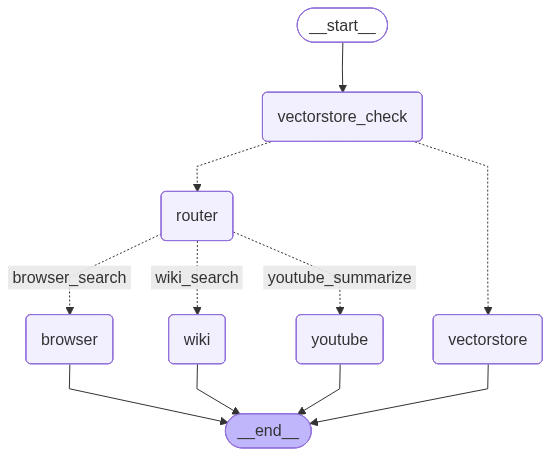

In [22]:
# Display graph
from IPython.display import Image, display
try:
  display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [55]:
result = app.invoke({
    "question": "what does this video say: https://www.youtube.com/watch?v=tUP5S4YdEJo?"
})
result

Score-----------------------------------------------
0.5670722909497928


{'question': 'what does this video say: https://www.youtube.com/watch?v=tUP5S4YdEJo?',
 'datasource': 'youtube_summarize',
 'documents': "Every day, organizations are striving to create perfect places. We understand that there are numerous challenges that may arise from achieving this goal. From meeting customer and staff expectations, managing operating costs, ensuring safety and security of people and assets, or achieving demanding sustainability targets. But our world is evolving and advancements in technologies bring new opportunities to overcome these challenges and gain efficiencies. The building industry alone is undergoing a major transformation. Buildings are talking and generating massive amounts of data. At Siemens, we support our customers with the digital transformation of their buildings. Through our combination of people, expertise, technology and services. We focus on not only capturing and analyzing the right data, but also generating data driven insight and taking act